# **Exploratory Data Analysis**

Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
df = pd.read_csv('cleaned_dataset.csv')

In [3]:
df.shape

(584356, 17)

In [ ]:
# Accessible chart style
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['axes.labelsize'] = 14  # Set the font size to 14 (or any desired size)

In [6]:
# Convert 'created_at' and 'customer_since' columns to datetime with errors='coerce'
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['customer_since'] = pd.to_datetime(df['customer_since'], errors='coerce')

#### Q: Do the online orders reliable.

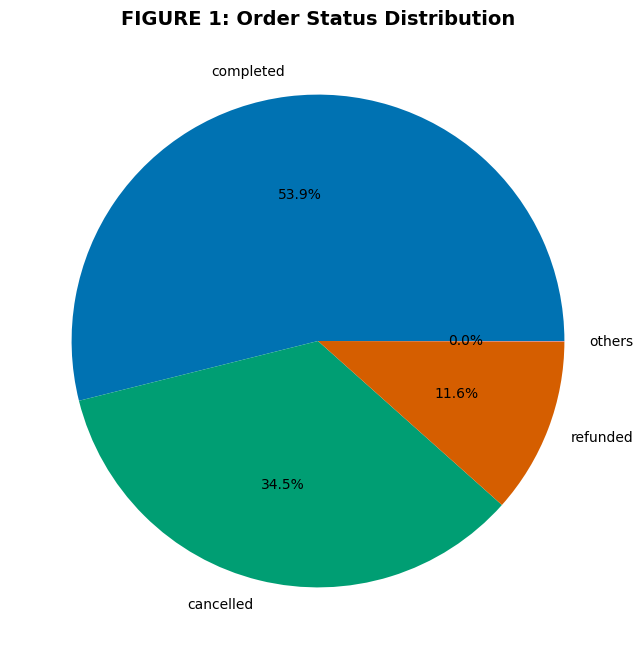

In [8]:
# Q: Do the online orders reliable.
status_counts = df['status'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
ax = plt.gca()  # Get the current Axes instance
ax.set_title("FIGURE 1: Order Status Distribution", fontsize=14, fontweight='bold')
plt.show()

#### Q: What the most purchased category?

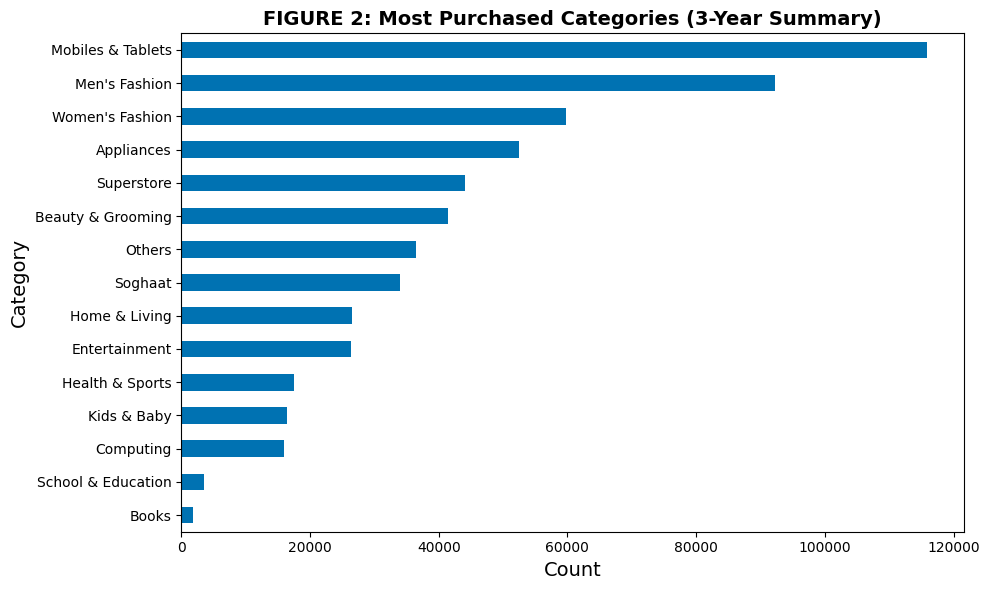

In [28]:
# Which category has been purchased the most
plt.figure(figsize=(10,6))
df['category_name'].value_counts().sort_values(ascending=True).plot(kind='barh')

plt.title("FIGURE 2: Most Purchased Categories (3-Year Summary)", fontsize=14, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Mobile and Tablets have been purchased the most followed by men's fashion and women's fashion. This signify the importance of Fashion items and electrons in the digital market.

#### Q: Price Distribution of orders

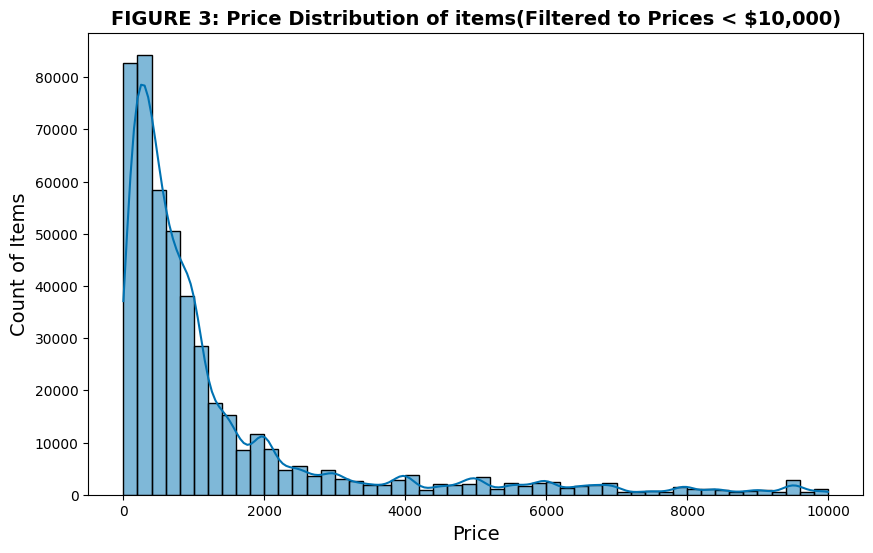

In [29]:
# Checking the price distribution of each product listed online and purchased by customer i:e not price of full order which would be price*qty

# to clearly see the distribution of the majority of products.
limit = 10000

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df['price'] < limit], # Filter the data for visualization
    x='price',
    bins=50,
    kde=True # Add a kernel density estimate line
)
plt.title(f'FIGURE 3: Price Distribution of items(Filtered to Prices < ${limit:,.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Count of Items')
plt.show()

The graph is right skewed. Most of the orders are priced in the range of 1 to 200 pkr. This means the E-commerce market shines in the low price items mostly with few number of listings/orders with high price.

#### Q: What is the average order amount per order status? Does cancelled orders have high price?

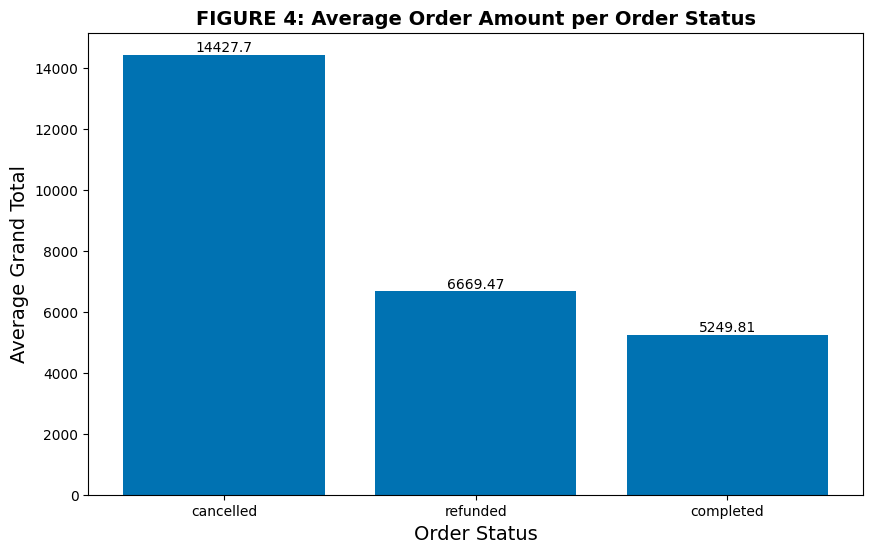

In [30]:
# compute average order amount per status
# Does cancelled orders have really high price


df_filtered = df[df['status']!='others']
status_amount = df_filtered.groupby('status')['grand_total'].mean().reset_index()

# sort by amount (optional for neat visualization)
status_amount = status_amount.sort_values('grand_total', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(status_amount['status'], status_amount['grand_total'])
# Add labels to the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')

plt.ylabel("Average Grand Total")
plt.xlabel("Order Status")
plt.title("FIGURE 4: Average Order Amount per Order Status", fontsize=14, fontweight='bold')
plt.show()


The cancelled orders are usually of high prices. That means high priced orders are highly unreliable. Mostly because of people prefer to purchase expensive things by physically checking it. 

#### Q: Which payment method is the most popular

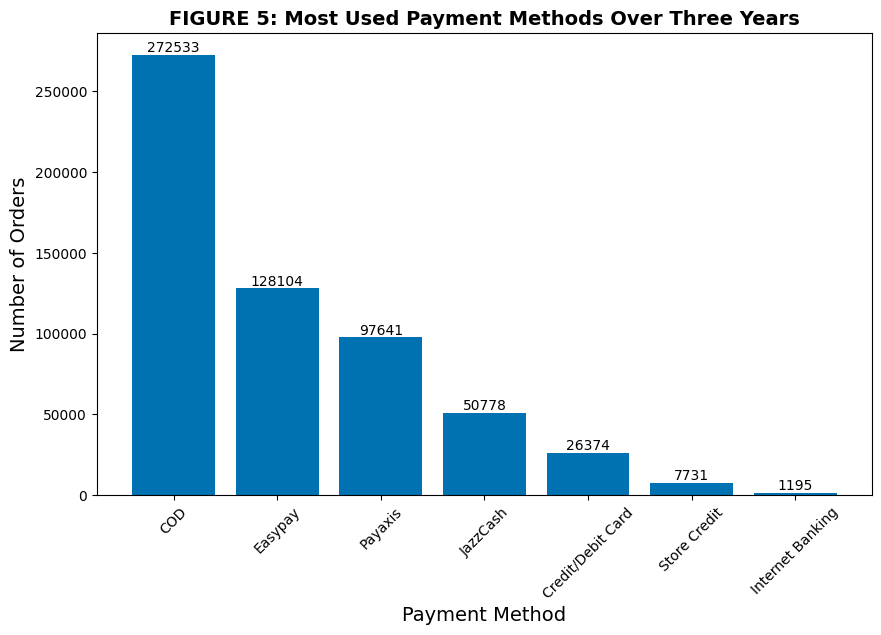

In [31]:
# Which payment method is the most popular
pm_counts = df['payment_method_clean'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(pm_counts.index, pm_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.xlabel("Payment Method")
# Add labels to the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')

plt.title("FIGURE 5: Most Used Payment Methods Over Three Years", fontsize=14, fontweight='bold')
plt.show()


Two payments methods come into play whenever we talk about online orders. One is Cash-on delivery and the second one is online payment. In online payments there are multiple gateways. From the above graph we can infer that among the different online payment methods available EasyPay is used as the most. Any new E-commerce store must prioritize incorporting EasyPay as online method.

#### Q which payment method is preffered across different price ranges?

C:\Users\khana\AppData\Local\Temp\ipykernel_11832\512876036.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1000x600 with 0 Axes>

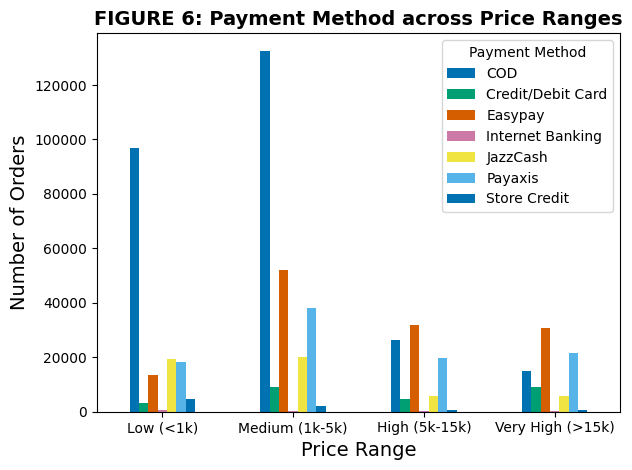

In [32]:
# Does people prefers to pay high order amount through COD
# Create price bins

bins = [0, 1000, 5000, 15000, df['grand_total'].max()]
labels = ['Low (<1k)', 'Medium (1k-5k)', 'High (5k-15k)', 'Very High (>15k)']

df['price_bin'] = pd.cut(df['grand_total'], bins=bins, labels=labels)

# Plot
plt.figure(figsize=(10,6))
df.groupby(['price_bin', 'payment_method_clean']).size().unstack().plot(kind='bar')

plt.xlabel("Price Range")
plt.ylabel("Number of Orders")
plt.title("FIGURE 6: Payment Method across Price Ranges", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Payment Method")
plt.tight_layout()
plt.show()


#### Q Which categories contribute most to revenue?

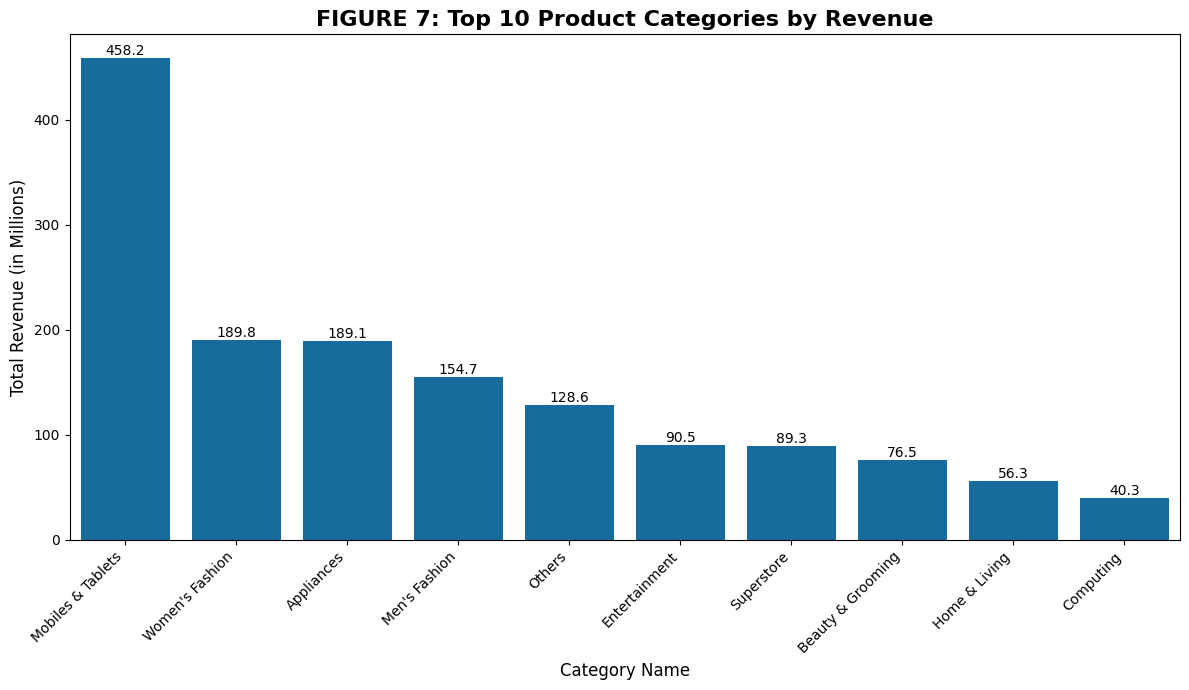

In [33]:

# Remove outliers from 'grand_total' using IQR
Q1 = df['grand_total'].quantile(0.25)
Q3 = df['grand_total'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to exclude outliers
filtered_df = df[(df['grand_total'] >= lower_bound) & (df['grand_total'] <= upper_bound)]

# Group by category and sum the grand total
category_revenue = (
    filtered_df.groupby('category_name')['grand_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Convert revenue to millions for better readability
category_revenue = category_revenue / 1e6

# Define the exact order for the y-axis labels
category_order = category_revenue.index

# Plot the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    y=category_revenue.values,
    x=category_revenue.index,
    order=category_order
)

# Improve aesthetics
plt.title('FIGURE 7: Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Category Name', fontsize=12)
plt.ylabel('Total Revenue (in Millions)', fontsize=12)

# Add labels to the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f', label_type='edge')

# Use tight_layout to prevent labels from being cut off
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Does high discount leads to more quantity ordered by the same customer?

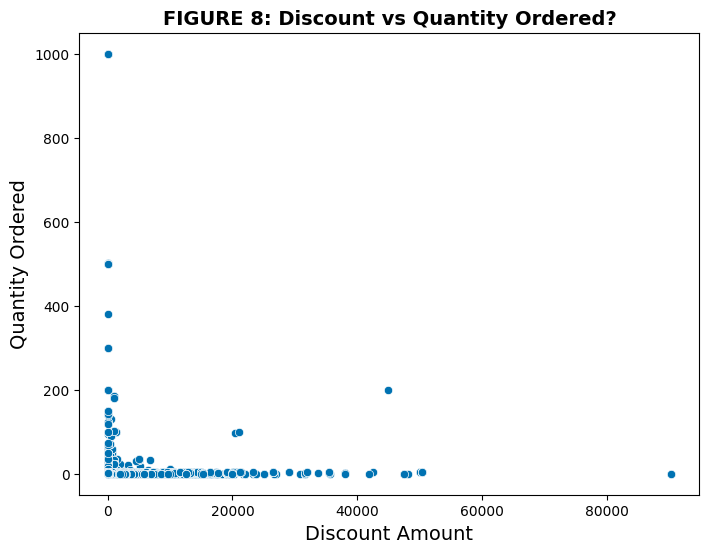

In [34]:
# Does high discount leads to more number of items ordered?
# Data Reduction can be performed -- Sampling or stratified Sampling

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='discount_amount',y='qty_ordered')
plt.xlabel("Discount Amount")
plt.ylabel("Quantity Ordered")
plt.title("FIGURE 8: Discount vs Quantity Ordered?",fontsize=14, fontweight='bold')
plt.show()

Both discount amount and quantity ordered are independent. It means that high discount doesn't offers more quantity ordered by the same customer. Customer only purchase the quantity according to its needs  

#### Q: Which categories have the highest repeat-purchase rate?

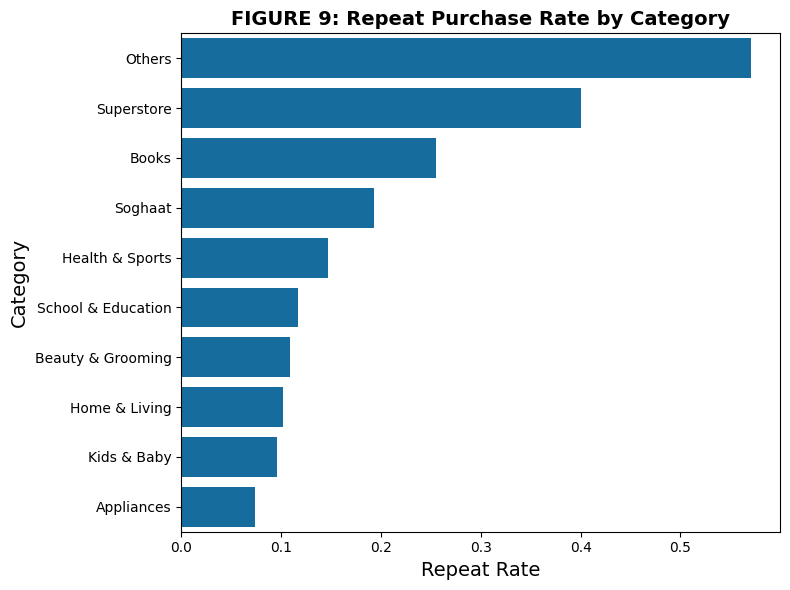

In [35]:


# Repeat = qty_ordered > 1 (simple proxy)
repeat_counts = df[df['qty_ordered'] > 1].groupby('category_name').size().reset_index(name='repeat_count')

# Total orders per category
total_counts = df.groupby('category_name').size().reset_index(name='total_count')

# Merge
repeat_df = repeat_counts.merge(total_counts, on='category_name', how='right').fillna(0)

# Calculate repeat rate
repeat_df['repeat_rate'] = repeat_df['repeat_count'] / repeat_df['total_count']

# Top 10
repeat_df = repeat_df.sort_values('repeat_rate', ascending=False).head(10)

# Visual
plt.figure(figsize=(8,6))
sns.barplot(data=repeat_df, y='category_name', x='repeat_rate')
plt.title('FIGURE 9: Repeat Purchase Rate by Category', fontsize=14, fontweight='bold')
plt.xlabel('Repeat Rate')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


Superstore items are purchased more frequently because this category includes household items. The household items are the basic needs of customers and they purhase them again and again. Secondly, books are the second most frequent purchased category. A key insight from this graph is the Kids and Baby Category are very less in number. This could be due to very few listings of items of kids online most probably due to the size issues in case of cloths. 

#### Q: Side by Side comparison of Volume vs Revenue across differnet categories

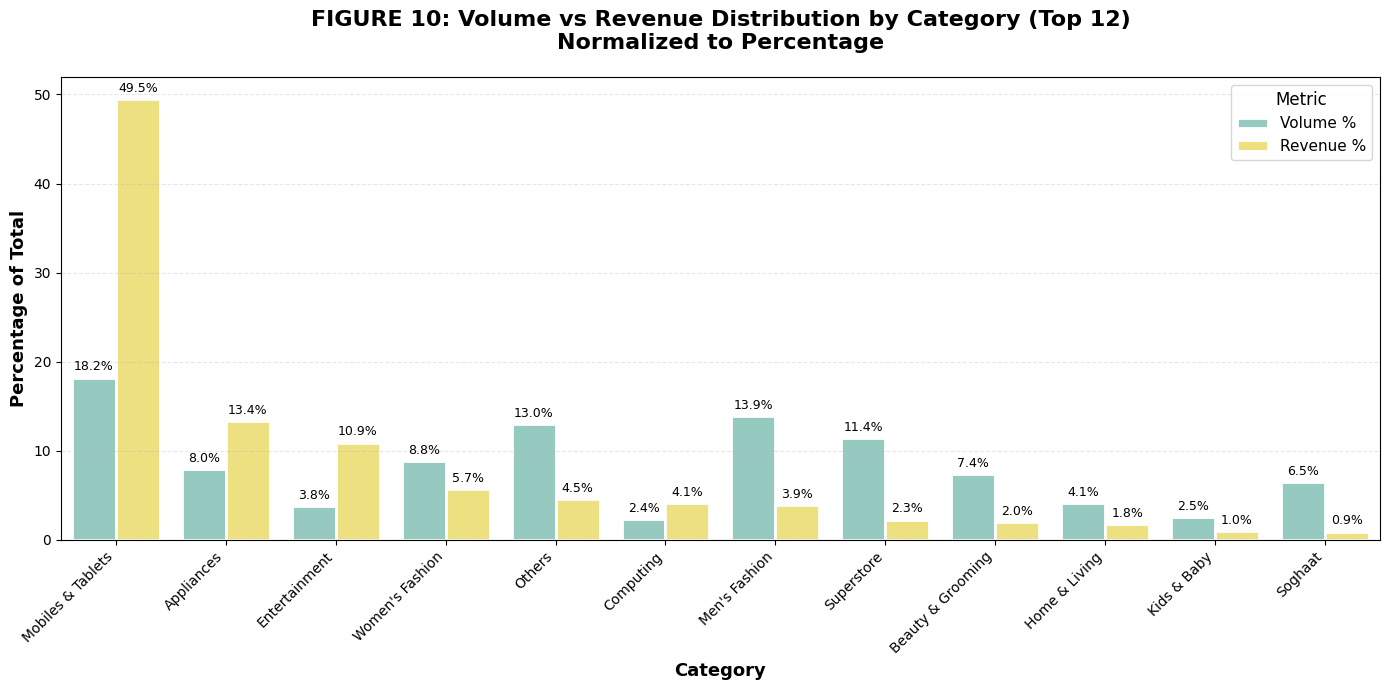

In [37]:

# Volume vs Revenue  Dual Axis Bar Chart (Normalized %)


cat_metrics = (
    df.groupby('category_name')
      .agg({'qty_ordered': 'sum', 'grand_total': 'sum'})
      .rename(columns={'qty_ordered': 'volume', 'grand_total': 'revenue'})
      .reset_index()
)

# Take top 12 categories
cat_metrics = cat_metrics.sort_values('revenue', ascending=False).head(12)

# Normalize to percentage of total
cat_metrics['volume_pct'] = (cat_metrics['volume'] / cat_metrics['volume'].sum()) * 100
cat_metrics['revenue_pct'] = (cat_metrics['revenue'] / cat_metrics['revenue'].sum()) * 100

# Melt for grouped bars
cat_melt = cat_metrics.melt(
    id_vars='category_name',
    value_vars=['volume_pct', 'revenue_pct'],
    var_name='Metric',
    value_name='Percentage'
)

# Rename for cleaner legend
cat_melt['Metric'] = cat_melt['Metric'].replace({
    'volume_pct': 'Volume %',
    'revenue_pct': 'Revenue %'
})

# Create plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=cat_melt,
    x='category_name',
    y='Percentage',
    hue='Metric',
    palette=['#8DD3C7', '#FFED6F'],
    edgecolor='white',
    linewidth=2
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

# Styling
plt.title('FIGURE 10: Volume vs Revenue Distribution by Category (Top 12)\nNormalized to Percentage',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=13, fontweight='bold')
plt.ylabel('Percentage of Total', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', fontsize=11, title_fontsize=12, loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### Q: What's the avg Order value across online and COD delivery payment method?

Original is_online values: [False  True]
Data types: bool
After mapping:   is_online   grand_total
0       COD   3926.391950
1    Online  12661.894086


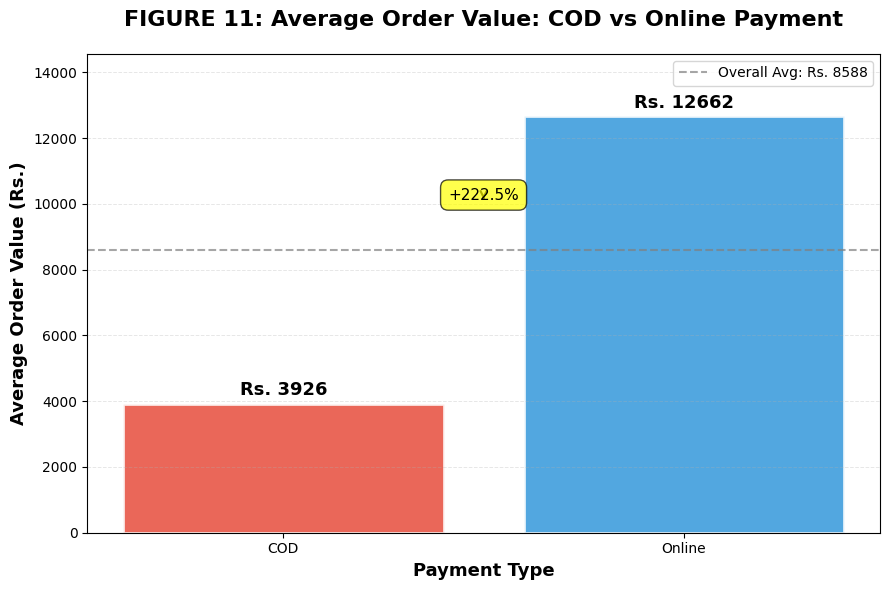

In [39]:
# Average Order Value: COD vs Online
df['is_online'] = df['payment_method_clean'] != 'COD'

aov = (
    df.groupby('is_online')['grand_total']
      .mean()
      .reset_index()
)

# Debug: Check what values exist
print("Original is_online values:", aov['is_online'].unique())
print("Data types:", aov['is_online'].dtype)

# Convert boolean to string directly
aov['is_online'] = aov['is_online'].astype(str).map({'True': 'Online', 'False': 'COD'})

# OR use this alternative approach:
# aov['is_online'] = aov['is_online'].apply(lambda x: 'Online' if x else 'COD')

# Debug: Check after mapping
print("After mapping:", aov)

# Check if we have both payment types
if len(aov) < 2:
    print("Warning: Not enough payment types found!")
    print(aov)
else:
    # Calculate the difference safely
    online_val = aov.loc[aov['is_online'] == 'Online', 'grand_total'].values
    cod_val = aov.loc[aov['is_online'] == 'COD', 'grand_total'].values
    
    if len(online_val) > 0 and len(cod_val) > 0:
        diff = online_val[0] - cod_val[0]
        diff_pct = (diff / cod_val[0]) * 100
        
        # Create figure
        plt.figure(figsize=(9, 6))
        
        # Create bar plot with better colors
        colors = ['#E74C3C', '#3498DB']  # Red for COD, Blue for Online
        bars = plt.bar(aov['is_online'], aov['grand_total'], color=colors,
                       edgecolor='white', linewidth=2, alpha=0.85)
        
        # Add value labels on bars
        for i, (idx, row) in enumerate(aov.iterrows()):
            plt.text(
                i,
                row['grand_total'] + (aov['grand_total'].max() * 0.02),
                f"Rs. {row['grand_total']:.0f}",
                ha='center',
                fontsize=13,
                fontweight='bold',
                color='black'
            )
        
        # Add average line
        avg_all = df['grand_total'].mean()
        plt.axhline(avg_all, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
                    label=f'Overall Avg: Rs. {avg_all:.0f}')
        
        # Add comparison annotation
        mid_point = 0.5
        plt.annotate(
            f'{diff_pct:+.1f}%' if diff > 0 else f'{diff_pct:.1f}%',
            xy=(mid_point, max(aov['grand_total']) * 0.8),
            ha='center',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black', lw=1.5)
        )
        
        # Styling
        plt.title('FIGURE 11: Average Order Value: COD vs Online Payment',
                  fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Payment Type', fontsize=13, fontweight='bold')
        plt.ylabel('Average Order Value (Rs.)', fontsize=13, fontweight='bold')
        
        # Add grid for better readability
        plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
        
        # Legend
        plt.legend(loc='upper right', fontsize=10)
        
        # Set y-axis to start from 0
        plt.ylim(0, aov['grand_total'].max() * 1.15)
        
        plt.tight_layout()
        plt.show()
        
    
    else:
        print("Error: Missing Online or COD data after mapping!")

#### Q: What are the habits of high spending customers?

C:\Users\khana\AppData\Local\Temp\ipykernel_11832\3997794693.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




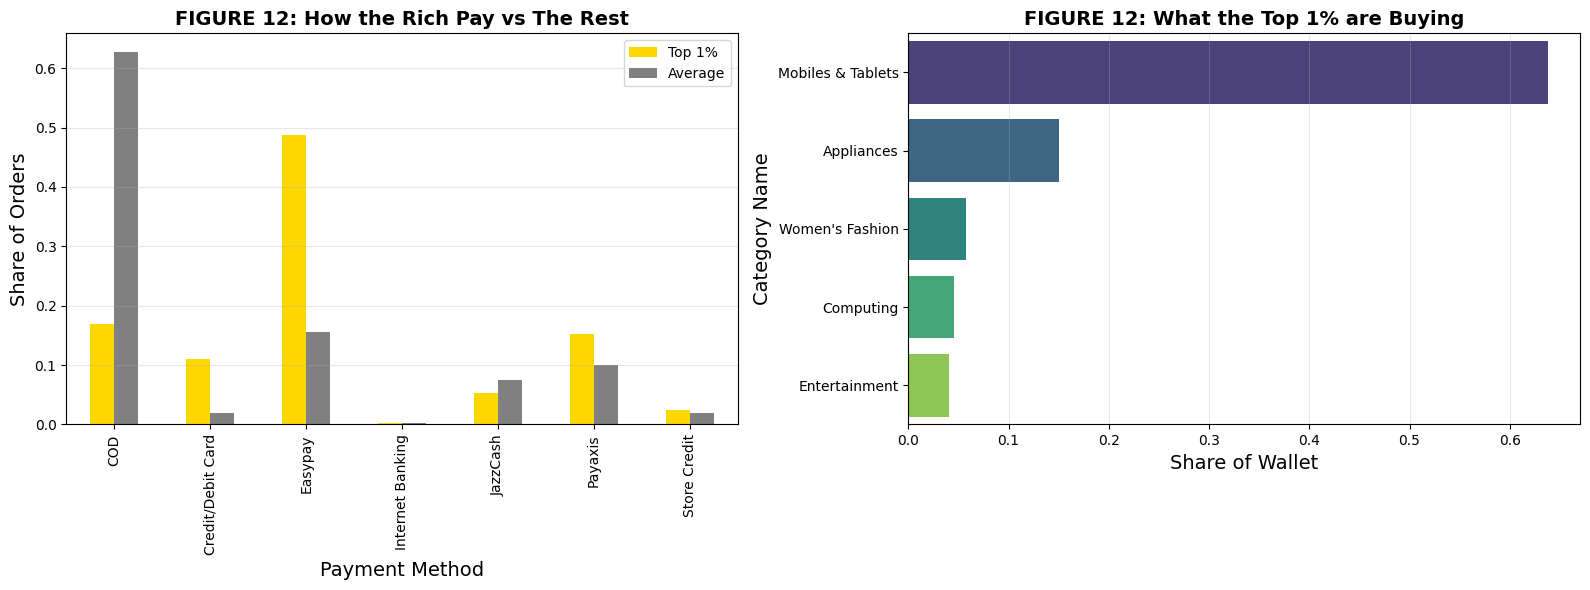

In [44]:
# 1. Filter for completed orders only (to analyze actual spending behavior)
df_completed = df[df['status'] == 'completed'].copy()

# 2. Determine the threshold for the top 1% of orders by value
threshold = df_completed['grand_total'].quantile(0.99)

# 3. Segment the data
df_completed['spender_type'] = df_completed['grand_total'].apply(lambda x: 'Top 1%' if x >= threshold else 'Average')

top_1_percent = df_completed[df_completed['spender_type'] == 'Top 1%']
average_spenders = df_completed[df_completed['spender_type'] == 'Average']

# 4. Prepare Data for Plotting
# Analysis 1: Category Preferences (Top 5)
top_category = top_1_percent['category_name'].value_counts(normalize=True).head(5)

# Analysis 2: Payment Methods
top_payment = top_1_percent['payment_method_clean'].value_counts(normalize=True)
avg_payment = average_spenders['payment_method_clean'].value_counts(normalize=True)

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Payment Method Comparison (Bar Chart)
payment_comp = pd.DataFrame({
    'Top 1%': top_payment,
    'Average': avg_payment
}).fillna(0)

payment_comp.plot(kind='bar', ax=axes[0], color=['gold', 'grey'])
axes[0].set_title('FIGURE 12: How the Rich Pay vs The Rest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Share of Orders')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top Categories for Top 1% (Horizontal Bar Chart)
sns.barplot(x=top_category.values, y=top_category.index, ax=axes[1], palette='viridis')
axes[1].set_title('FIGURE 12: What the Top 1% are Buying', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Share of Wallet')
axes[1].set_ylabel('Category Name')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#### Q: COD VS Online: Better for earning money for the buinesses?


C:\Users\khana\AppData\Local\Temp\ipykernel_11832\1086532217.py:35: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\khana\AppData\Local\Temp\ipykernel_11832\1086532217.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\khana\AppData\Local\Temp\ipykernel_11832\1086532217.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




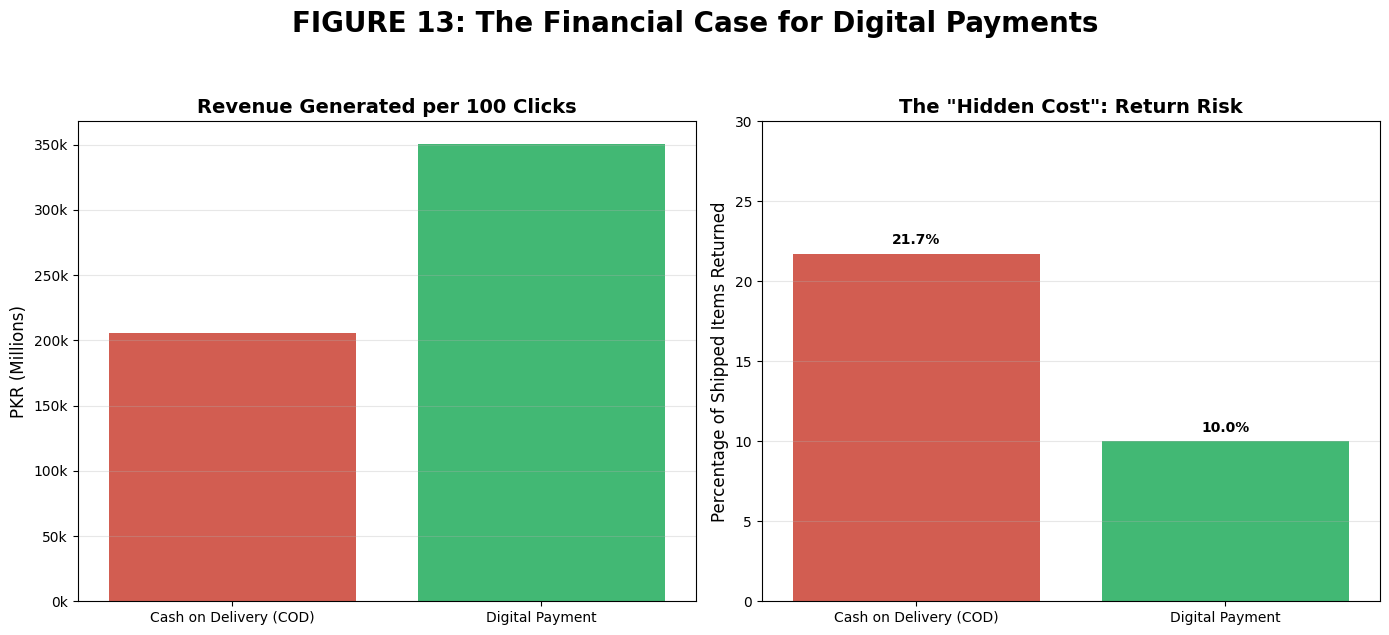

In [45]:

# 2. Categorize Payment Methods
def categorize_payment(method):
    if method == 'COD':
        return 'Cash on Delivery (COD)'
    else:
        return 'Digital Payment'

df['pay_type'] = df['payment_method_clean'].apply(categorize_payment)

# 3. Calculate Key Business Metrics
def payment_metrics(x):
    total = len(x)
    cancelled = (x['status'] == 'cancelled').sum()

    # "Shipped" includes completed and refunded orders
    shipped = (x['status'] == 'completed').sum() + (x['status'] == 'refunded').sum()
    refunded = (x['status'] == 'refunded').sum()
    completed = (x['status'] == 'completed').sum()

    # Average Order Value (only count completed sales)
    completed_orders = x[x['status'] == 'completed']
    aov = completed_orders['grand_total'].mean() if len(completed_orders) > 0 else 0

    # Completion Rate
    completion_rate = (completed / total) if total > 0 else 0

    return pd.Series({
        # Metric: If 100 people click "Buy", how much money do we keep?
        'Revenue per 100 Orders': completion_rate * aov * 100,

        # Metric: What % of shipped boxes come back?
        'Return Risk (%)': (refunded / shipped) * 100 if shipped > 0 else 0
    })

metrics = df.groupby('pay_type').apply(payment_metrics).reset_index()

# 4. Visualization (2 Panels Only)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('FIGURE 13: The Financial Case for Digital Payments', fontsize=20, fontweight='bold', y=1.05)

# Plot 1: Revenue per 100 Orders (The "Value")
sns.barplot(data=metrics, x='pay_type', y='Revenue per 100 Orders', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Revenue Generated per 100 Clicks', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PKR (Millions)', fontsize=12)
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Return Risk (The "Cost")
sns.barplot(data=metrics, x='pay_type', y='Return Risk (%)', ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('The "Hidden Cost": Return Risk', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage of Shipped Items Returned', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylim(0, 30)
axes[1].grid(axis='y', alpha=0.3)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

#### Q: Digital Payment with discount depth

C:\Users\khana\AppData\Local\Temp\ipykernel_11832\3753245243.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



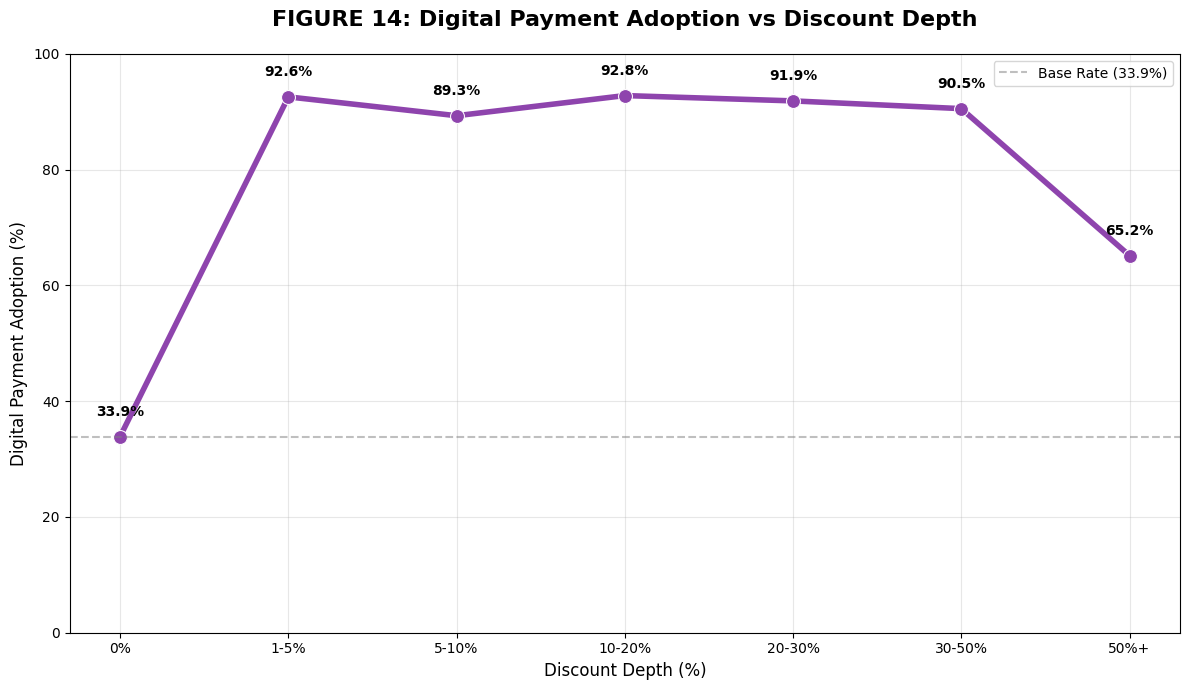

In [48]:


df['discount_pct'] = (df['discount_amount'] / df['gross_amount']) * 100
df['discount_pct'] = df['discount_pct'].clip(0, 100)

# 2. Create Discount Bins
bins = [-1, 0.1, 5, 10, 20, 30, 50, 101]
labels = ['0%', '1-5%', '5-10%', '10-20%', '20-30%', '30-50%', '50%+']
df['discount_bin'] = pd.cut(df['discount_pct'], bins=bins, labels=labels)

# 3. Categorize Payment (1 = Digital, 0 = COD)
def categorize_payment(method):
    if method == 'COD':
        return 0
    else:
        return 1

df['is_digital'] = df['payment_method_clean'].apply(categorize_payment)

# 4. Calculate Digital Adoption % per Bin
adoption_curve = df.groupby('discount_bin')['is_digital'].mean() * 100

# 5. Plotting
plt.figure(figsize=(12, 7))
sns.lineplot(x=adoption_curve.index, y=adoption_curve.values, marker='o', color='#8e44ad', linewidth=4, markersize=10)

# Reference Line (Base Rate)
base_rate = adoption_curve.iloc[0]
plt.axhline(y=base_rate, color='gray', linestyle='--', alpha=0.5, label=f'Base Rate ({base_rate:.1f}%)')

# Styling
plt.title('FIGURE 14: Digital Payment Adoption vs Discount Depth',
                  fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Depth (%)', fontsize=12)
plt.ylabel('Digital Payment Adoption (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

# Annotate values
for i, txt in enumerate(adoption_curve.values):
    plt.annotate(f'{txt:.1f}%', (adoption_curve.index[i], adoption_curve.values[i]),
                 xytext=(0, 15), textcoords='offset points', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Q: Which Category is purchased frequently?

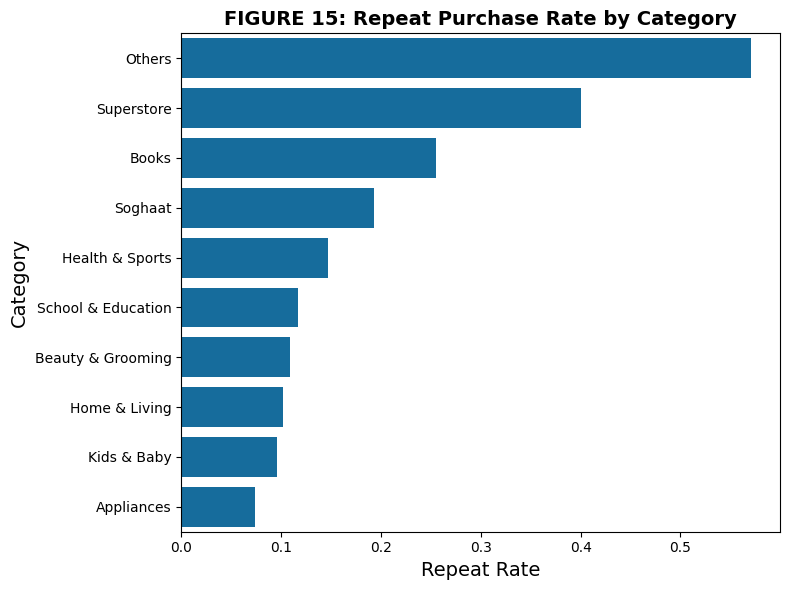

In [11]:


# Repeat = qty_ordered > 1 (simple proxy)
repeat_counts = df[df['qty_ordered'] > 1].groupby('category_name').size().reset_index(name='repeat_count')

# Total orders per category
total_counts = df.groupby('category_name').size().reset_index(name='total_count')

# Merge
repeat_df = repeat_counts.merge(total_counts, on='category_name', how='right').fillna(0)

# Calculate repeat rate
repeat_df['repeat_rate'] = repeat_df['repeat_count'] / repeat_df['total_count']

# Top 10
repeat_df = repeat_df.sort_values('repeat_rate', ascending=False).head(10)

# Visual
plt.figure(figsize=(8,6))
sns.barplot(data=repeat_df, y='category_name', x='repeat_rate')
plt.title('FIGURE 15: Repeat Purchase Rate by Category', fontsize=14, fontweight='bold')
plt.xlabel('Repeat Rate')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


#### Q: How has online payment adoption evolved from 2016 to 2018?

In [49]:
# Extract year from created_at
df['year'] = df['created_at'].dt.year

adopt_df = df.groupby('year')['is_online'].mean().reset_index()

fig = px.line(
    adopt_df,
    x='year',
    y='is_online',
    title='FIGURE 16: Online Payment Adoption (2016–2018)',
    labels={'is_online': 'Adoption Rate'}
)

fig.update_layout(plot_bgcolor='white')
fig.show()


C:\Users\khana\AppData\Local\Temp\ipykernel_11832\2142070218.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




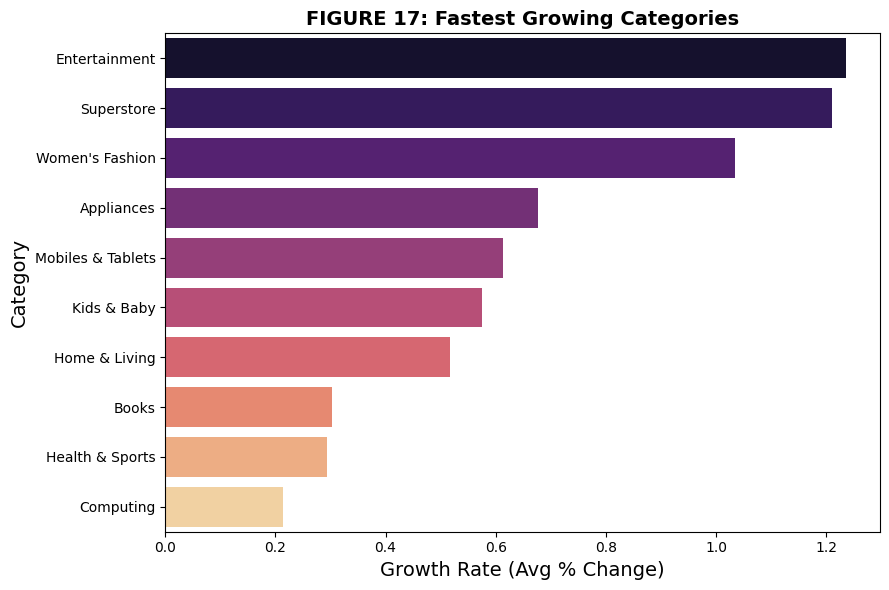

In [54]:
# Calculate year-over-year growth per category
sample_df = df[df['category_name']!= 'Others']
growth = (
    sample_df.groupby(['year', 'category_name'])
      .size()
      .unstack()
      .pct_change()
      .mean()
      .reset_index(name='growth')
)

growth = growth.sort_values('growth', ascending=False).head(10)

plt.figure(figsize=(9,6))
sns.barplot(data=growth, y='category_name', x='growth', palette='magma')
plt.title('FIGURE 17: Fastest Growing Categories', fontsize=14, fontweight='bold')
plt.xlabel('Growth Rate (Avg % Change)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [55]:

# discount indicator
if 'discount_amount' in df.columns:
    df['has_discount'] = df['discount_amount'] > 0
else:
    df['has_discount'] = 0
# Get top 10 categories by total sales
top_cats = df.groupby('category_name')['qty_ordered'].sum().nlargest(10).index

# Filter and aggregate
disc_sales = (
    df[df['category_name'].isin(top_cats)]
    .groupby(['category_name', 'has_discount'])['qty_ordered']
    .sum()
    .reset_index()
)

# Rename for clarity
disc_sales['discount_status'] = disc_sales['has_discount'].map({
    True: 'With Discount',
    False: 'Without Discount'
})

# Create grouped bar chart
fig = px.bar(
    disc_sales,
    x='category_name',
    y='qty_ordered',
    color='discount_status',
    barmode='group',
    title='<b>FIGURE 18: Sales Impact: With vs Without Discounts</b><br><sub>Top 10 Categories</sub>',
    labels={
        'category_name': 'Category',
        'qty_ordered': 'Total Orders',
        'discount_status': 'Discount Status'
    },
    color_discrete_map={
        'With Discount': '#E74C3C',      # Red
        'Without Discount': '#3498DB'    # Blue
    },
    text='qty_ordered'
)

fig.update_traces(
    texttemplate='%{text:,}',
    textposition='outside',
    marker_line_color='white',
    marker_line_width=2
)

fig.update_layout(
    plot_bgcolor='#F8F9FA',
    xaxis_tickangle=-45,
    font=dict(size=12),
    title_font_size=16,
    xaxis_title_font_size=13,
    yaxis_title_font_size=13,
    legend=dict(
        title='',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    height=600,
    margin=dict(b=150, t=100)
)

fig.show()

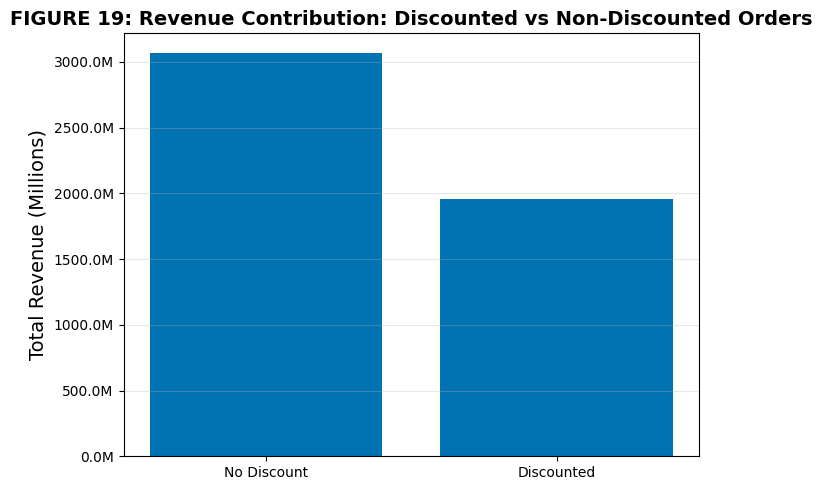

In [ ]:
# ----------------------------------------------
#  PREP
# ----------------------------------------------

# Discount flag
df["is_discounted"] = df["discount_amount"] > 0

# Potential revenue (list price)
df["potential_revenue"] = df["price"] * df["qty_ordered"]

# Discount ratio (how steep are the discounts relative to list price)
df["discount_ratio"] = df["discount_amount"] / df["potential_revenue"]
df["discount_ratio"] = df["discount_ratio"].fillna(0)

#  1 — Revenue from discounted vs non-discounted
discount_revenue = df.groupby("is_discounted")["grand_total"].sum()
discount_revenue.index = ["No Discount", "Discounted"]

plt.figure(figsize=(7,5))
plt.bar(discount_revenue.index, discount_revenue.values)
plt.title("FIGURE 19: Revenue Contribution: Discounted vs Non-Discounted Orders", fontsize=14, fontweight='bold')
plt.ylabel("Total Revenue (Millions)")

# Format y-axis to show values in millions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()




                      cancel_rate  total_orders  cancel_rate_pct
payment_method_clean                                            
Credit/Debit Card        0.715177         26297        71.517664
Payaxis                  0.628013         97592        62.801254
Easypay                  0.573264        128044        57.326388
JazzCash                 0.500000         50736        50.000000
Internet Banking         0.393305          1195        39.330544
COD                      0.081215        270959         8.121524
Store Credit             0.010503          7617         1.050282


C:\Users\khana\AppData\Local\Temp\ipykernel_11832\1664751921.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




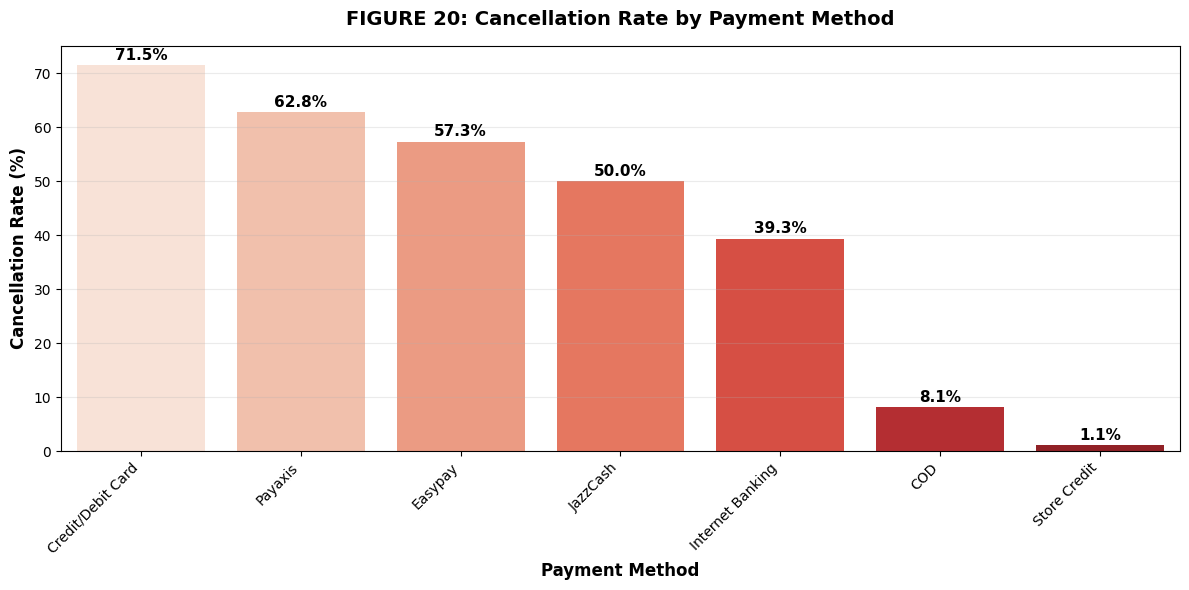

C:\Users\khana\AppData\Local\Temp\ipykernel_11832\1664751921.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




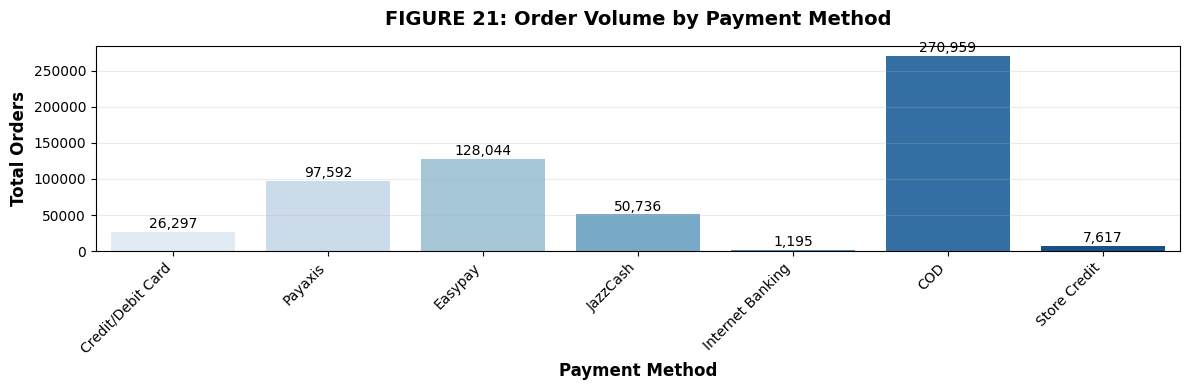

In [59]:

cancel_states = ["cancelled", "canceled", "void", "refused", "rejected"]

df['status_clean'] = df['status'].str.lower().str.strip()
df['is_cancelled'] = df['status_clean'].isin(cancel_states).astype(int)

# ---------------------------------------------
# 2. Group and compute rates
# ---------------------------------------------
cancel_rates = (
    df.groupby('payment_method_clean')['is_cancelled']
    .agg(cancel_rate='mean', total_orders='count')
    .sort_values('cancel_rate', ascending=False)
)

cancel_rates['cancel_rate_pct'] = cancel_rates['cancel_rate'] * 100

print(cancel_rates)

# ---------------------------------------------
# 3. Improved Visualization: Cancellation Rate
# ---------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cancel_rates.reset_index(),
    x='payment_method_clean',
    y='cancel_rate_pct',
    palette='Reds'
)

plt.ylabel("Cancellation Rate (%)", fontsize=12, fontweight='bold')
plt.xlabel("Payment Method", fontsize=12, fontweight='bold')
plt.title("FIGURE 20: Cancellation Rate by Payment Method", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.25)

# Add labels atop bars
for i, row in enumerate(cancel_rates.reset_index().itertuples()):
    plt.text(
        i,
        row.cancel_rate_pct + 1,
        f"{row.cancel_rate_pct:.1f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------
# 4. Secondary Insight: Orders by Method (Optional)
# ---------------------------------------------
plt.figure(figsize=(12, 4))
sns.barplot(
    data=cancel_rates.reset_index(),
    x='payment_method_clean',
    y='total_orders',
    palette='Blues'
)

plt.ylabel("Total Orders", fontsize=12, fontweight='bold')
plt.xlabel("Payment Method", fontsize=12, fontweight='bold')
plt.title("FIGURE 21: Order Volume by Payment Method", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.25)

for i, row in enumerate(cancel_rates.reset_index().itertuples()):
    plt.text(
        i,
        row.total_orders + (cancel_rates['total_orders'].max() * 0.02),
        f"{row.total_orders:,}",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

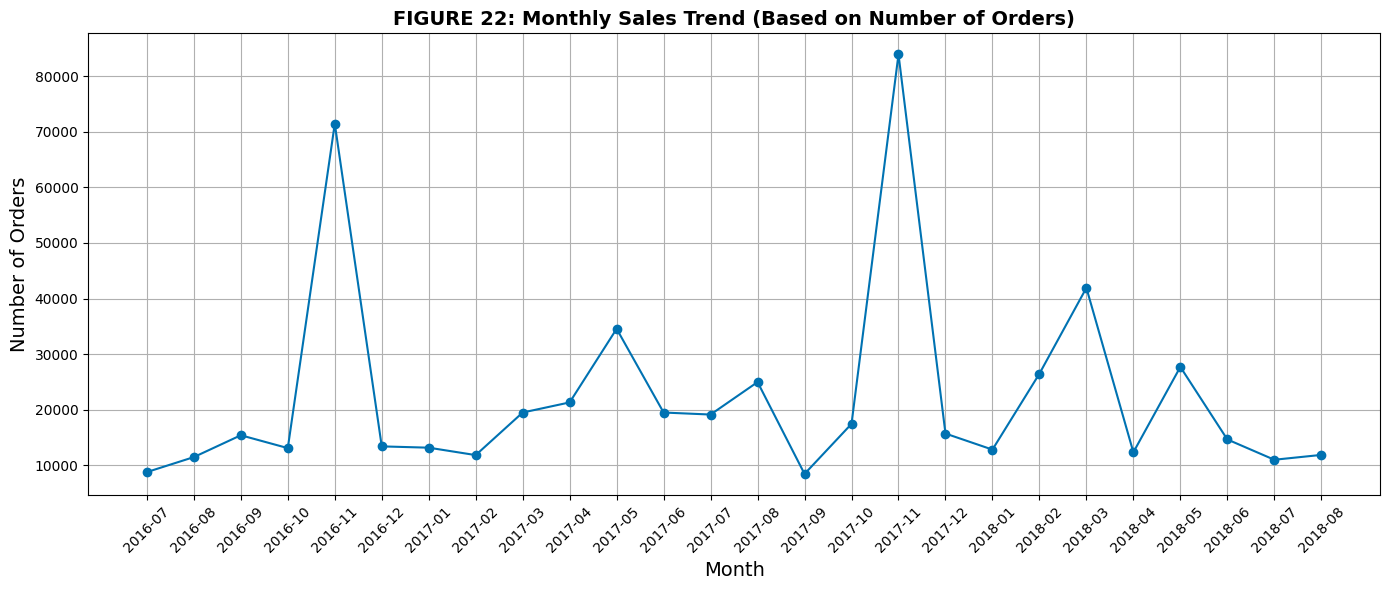

In [61]:
# Daraz 11-11
df['order_month'] = df['created_at'].dt.to_period('M')   # Example: 2017-06
monthly_orders = df.groupby('order_month').size().reset_index(name='num_orders')

plt.figure(figsize=(14,6))
plt.plot(monthly_orders['order_month'].astype(str),
         monthly_orders['num_orders'],
         marker='o')

plt.xticks(rotation=45)
plt.title("FIGURE 22: Monthly Sales Trend (Based on Number of Orders)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.tight_layout()
plt.show()